In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def normalize_db_name(name):
    n = re.sub(r'\.vcf\.gz$', '', name)   # drop the extension first
    n = re.sub(r'(?i)alu', '', n)
    n = re.sub(r'(?i)line1', '', n)
    n = re.sub(r'[_.]+', '_', n)        
    n = n.strip('_.')
    return n

RAW_DB_NAMES = [
    "INS.ALU.solo.hg38.vcf.gz", "INS.LINE1.solo.hg38.vcf.gz",
    "3202_30X_1KGP_INS_ALU.vcf.gz", "3202_30X_1KGP_INS_LINE1.vcf.gz",
    "1kgp_INS_ALU.vcf.gz", "1kgp_INS_LINE1.vcf.gz",
    "HMEID.ALU.vcf.gz", "HMEID.LINE1.vcf.gz",
    "nstd211.ALU.dedup.vcf.gz", "nstd211.LINE1.dedup.vcf.gz",
    "gnomad_INS_ALU.vcf.gz", "gnomad_INS_LINE1.vcf.gz",
    "SGDP_INS_ALU.vcf.gz", "SGDP_INS_LINE1.vcf.gz",
    "Indigen_Alu_final_geno10_all_22K.vcf.gz",
]
NORMALIZED_DB_NAMES = sorted(set(normalize_db_name(n) for n in RAW_DB_NAMES))
print(NORMALIZED_DB_NAMES) 

n = len(NORMALIZED_DB_NAMES)
_colors = [mcolors.hsv_to_rgb((i / n, 0.65, 0.85)) for i in range(n)]
DB_COLOR_MAP = {name: _colors[i] for i, name in enumerate(NORMALIZED_DB_NAMES)}

def get_db_color(name):
    key = normalize_db_name(name)
    if key in DB_COLOR_MAP:
        return DB_COLOR_MAP[key]
    h = (hash(key) % 1000) / 1000
    return mcolors.hsv_to_rgb((h, 0.65, 0.85))

DB_SHORT_LABEL_MAP = {
    "INS_solo_hg38":"1KGP-LR",
    "3202_30X_1KGP_INS":"1KGP-30X",
    "1kgp_INS":"1KGP-7.4X",
    "HMEID":"HMEID",
    "nstd211_dedup":"nstd211",
    "gnomad_INS":"gnomAD-SV",
    "SGDP_INS":"SGDP",
    "Indigen_final_geno10_all_22K":"IndiGen",
}

def get_db_short_label(name):
    key = normalize_db_name(name)
    return DB_SHORT_LABEL_MAP.get(key, key)  

def db_key_table():
    """Short label -> normalized db name, for whatever's in DB_SHORT_LABEL_MAP."""
    return pd.DataFrame(
        [(label, name) for name, label in DB_SHORT_LABEL_MAP.items()],
        columns=["label", "source_db"],
    ).sort_values("label").reset_index(drop=True)

['1kgp_INS', '3202_30X_1KGP_INS', 'HMEID', 'INS_solo_hg38', 'Indigen_final_geno10_all_22K', 'SGDP_INS', 'gnomad_INS', 'nstd211_dedup']


In [6]:
%%bash
module load bcftools-1.21
module load bedtools-2.30

GI_VCF="/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz"

LR_SR_VCFS=(
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/hg38_longreads_SVAN/INS.ALU.solo.hg38.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_ALU.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_ALU.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.ALU.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.ALU.dedup.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_ALU.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_ALU.vcf.gz"
    "/gpfs/data/user/ruchitha/MELT/Analysis/NoveltyCheck/databases/IndiGen/Indigen_Alu_final_geno10_all_22K.vcf.gz"
)

WINDOWS=(5 10 20 50 100 250 500)
AF_THRESHOLD=0

TMPDIR=$(mktemp -d /tmp/alu_window_XXXX)
echo "TMPDIR=${TMPDIR}"  

NOVEL_TSV="${TMPDIR}/novel_by_window.tsv"
PERDB_TSV="${TMPDIR}/overlap_by_window_and_db.tsv"

echo -e "window_bp\tnovel_count\tpct_of_gi_variants" > "${NOVEL_TSV}"
echo -e "window_bp\tsource_vcf\tgi_variants_overlapping\tpct_of_gi_variants" > "${PERDB_TSV}"

bcftools view -H "${GI_VCF}" \
| awk -F'\t' -v AFTHRESH="${AF_THRESHOLD}" '{
    split($8, info, ";");
    for (i in info) {
        if (info[i] ~ /^AF=/) {
            split(info[i], af, "=");
            if (af[2]+0 >= AFTHRESH)
                print $1"\t"$2"\t"$2
        }
    }
}' \
| sort -k1,1 -k2,2n \
> "${TMPDIR}/gi_coords.txt"

N_GI=$(wc -l < "${TMPDIR}/gi_coords.txt")
echo "GI variants (AF>=${AF_THRESHOLD}): ${N_GI}"

declare -A PERVCF_COORD_FILES

for VCF in "${LR_SR_VCFS[@]}"; do
    if [[ ! -f "$VCF" ]]; then
        echo "WARNING: skipping missing file: $VCF"
        continue
    fi
    BASENAME=$(basename "$VCF")
    PERVCF_COORDS="${TMPDIR}/$(basename "$VCF" .vcf.gz).coords.txt"

    bcftools query -f '%CHROM\t%POS\t%POS\n' "${VCF}" \
    | awk 'BEGIN{OFS="\t"}{
        chrom = $1
        if (chrom !~ /^chr/) chrom = "chr"chrom
        print chrom, $2, $3
    }' \
    | sort -k1,1 -k2,2n \
    > "${PERVCF_COORDS}"

    PERVCF_COORD_FILES["${BASENAME}"]="${PERVCF_COORDS}"
done

> "${TMPDIR}/lr_union.txt"
for BASENAME in "${!PERVCF_COORD_FILES[@]}"; do
    cat "${PERVCF_COORD_FILES[$BASENAME]}" >> "${TMPDIR}/lr_union.txt"
done
sort -k1,1 -k2,2n "${TMPDIR}/lr_union.txt" | uniq > "${TMPDIR}/lr_union_sorted.txt"
echo "Total LR/SR coords (union, deduplicated): $(wc -l < ${TMPDIR}/lr_union_sorted.txt)"
echo ""

#loop over window sizes
for WINDOW in "${WINDOWS[@]}"; do
    echo "WINDOW = ${WINDOW} bp"

    for BASENAME in "${!PERVCF_COORD_FILES[@]}"; do
        PERVCF_COORDS="${PERVCF_COORD_FILES[$BASENAME]}"

        bedtools window -a "${TMPDIR}/gi_coords.txt" -b "${PERVCF_COORDS}" -w "${WINDOW}" \
        | cut -f1-3 | sort -u > "${TMPDIR}/gi_matched_thisvcf.txt"

        N_MATCHED=$(wc -l < "${TMPDIR}/gi_matched_thisvcf.txt")
        PCT=$(awk -v m="${N_MATCHED}" -v t="${N_GI}" 'BEGIN{ if (t==0) print "NA"; else printf "%.2f", (m/t)*100 }')

        echo "  ${BASENAME}: ${N_MATCHED} GI variants overlap (${PCT}%)"
        echo -e "${WINDOW}\t${BASENAME}\t${N_MATCHED}\t${PCT}" >> "${PERDB_TSV}"
    done

    bedtools window -a "${TMPDIR}/gi_coords.txt" -b "${TMPDIR}/lr_union_sorted.txt" -w "${WINDOW}" \
    | cut -f1-3 | sort -u > "${TMPDIR}/gi_matched.txt"

    bedtools intersect -a "${TMPDIR}/gi_coords.txt" -b "${TMPDIR}/gi_matched.txt" -v \
    > "${TMPDIR}/gi_novel_thiswindow.txt"

    N_NOVEL=$(wc -l < "${TMPDIR}/gi_novel_thiswindow.txt")
    PCT_NOVEL=$(awk -v m="${N_NOVEL}" -v t="${N_GI}" 'BEGIN{ if (t==0) print "NA"; else printf "%.2f", (m/t)*100 }')

    echo "  --> NOVEL (not in any LR/SR VCF): ${N_NOVEL} (${PCT_NOVEL}%)"
    echo -e "${WINDOW}\t${N_NOVEL}\t${PCT_NOVEL}" >> "${NOVEL_TSV}"
    echo ""
done

echo "# Novel variant counts by window size"
column -t "${NOVEL_TSV}"

echo "# Per-DB overlap counts by window size"
column -t "${PERDB_TSV}"

TMPDIR=/tmp/alu_window_vjgS


[W::bcf_hdr_check_sanity] GL should be declared as Number=G


GI variants (AF>=0): 26977


[W::bcf_hrec_check] Invalid tag name: "5PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_SEQ"


Total LR/SR coords (union, deduplicated): 242929

WINDOW = 5 bp
  nstd211.ALU.dedup.vcf.gz: 8908 GI variants overlap (33.02%)
  INS.ALU.solo.hg38.vcf.gz: 3566 GI variants overlap (13.22%)
  HMEID.ALU.vcf.gz: 7564 GI variants overlap (28.04%)
  1kgp_INS_ALU.vcf.gz: 4551 GI variants overlap (16.87%)
  gnomad_INS_ALU.vcf.gz: 6189 GI variants overlap (22.94%)
  3202_30X_1KGP_INS_ALU.vcf.gz: 6319 GI variants overlap (23.42%)
  SGDP_INS_ALU.vcf.gz: 5937 GI variants overlap (22.01%)
  Indigen_Alu_final_geno10_all_22K.vcf.gz: 7004 GI variants overlap (25.96%)
  --> NOVEL (not in any LR/SR VCF): 14299 (53.00%)

WINDOW = 10 bp
  nstd211.ALU.dedup.vcf.gz: 8914 GI variants overlap (33.04%)
  INS.ALU.solo.hg38.vcf.gz: 5130 GI variants overlap (19.02%)
  HMEID.ALU.vcf.gz: 7590 GI variants overlap (28.14%)
  1kgp_INS_ALU.vcf.gz: 4743 GI variants overlap (17.58%)
  gnomad_INS_ALU.vcf.gz: 6607 GI variants overlap (24.49%)
  3202_30X_1KGP_INS_ALU.vcf.gz: 6515 GI variants overlap (24.15%)
  SGDP_INS_ALU.

250        SGDP_INS_ALU.vcf.gz                      5974                     22.14
250        Indigen_Alu_final_geno10_all_22K.vcf.gz  7107                     26.34
500        nstd211.ALU.dedup.vcf.gz                 9170                     33.99
500        INS.ALU.solo.hg38.vcf.gz                 6463                     23.96
500        HMEID.ALU.vcf.gz                         7847                     29.09
500        1kgp_INS_ALU.vcf.gz                      5888                     21.83
500        gnomad_INS_ALU.vcf.gz                    9925                     36.79
500        3202_30X_1KGP_INS_ALU.vcf.gz             7656                     28.38
500        SGDP_INS_ALU.vcf.gz                      5998                     22.23
500        Indigen_Alu_final_geno10_all_22K.vcf.gz  7147                     26.49


Novel ALU variants (not in ANY db) by window size:


,window_bp,novel_count,pct_of_gi_variants
0,5,14299,53.00
1,10,14274,52.91
2,20,14224,52.73
3,50,14122,52.35
4,100,13963,51.76
5,250,13606,50.44
6,500,13067,48.44



Overlapping variant counts by window size and source DB:


source_vcf,1KGP-7.4X,1KGP-30X,HMEID,1KGP-LR,IndiGen,SGDP,gnomAD-SV,nstd211
window_bp,,,,,,,,
5,4551,6319,7564,3566,7004,5937,6189,8908
10,4743,6515,7590,5130,7010,5941,6607,8914
20,5449,7447,7677,6244,7050,5944,8670,8934
50,5539,7474,7696,6338,7058,5947,8801,8953
100,5616,7499,7715,6374,7075,5952,8971,8976
250,5794,7560,7764,6408,7107,5974,9315,9058
500,5888,7656,7847,6463,7147,5998,9925,9170



DB code key:


,label,source_db
0,1KGP-30X,3202_30X_1KGP_INS
1,1KGP-7.4X,1kgp_INS
2,1KGP-LR,INS_solo_hg38
3,HMEID,HMEID
4,IndiGen,Indigen_final_geno10_all_22K
5,SGDP,SGDP_INS
6,gnomAD-SV,gnomad_INS
7,nstd211,nstd211_dedup


  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/per_db_ALU_overlap_by_window.pdf / .png


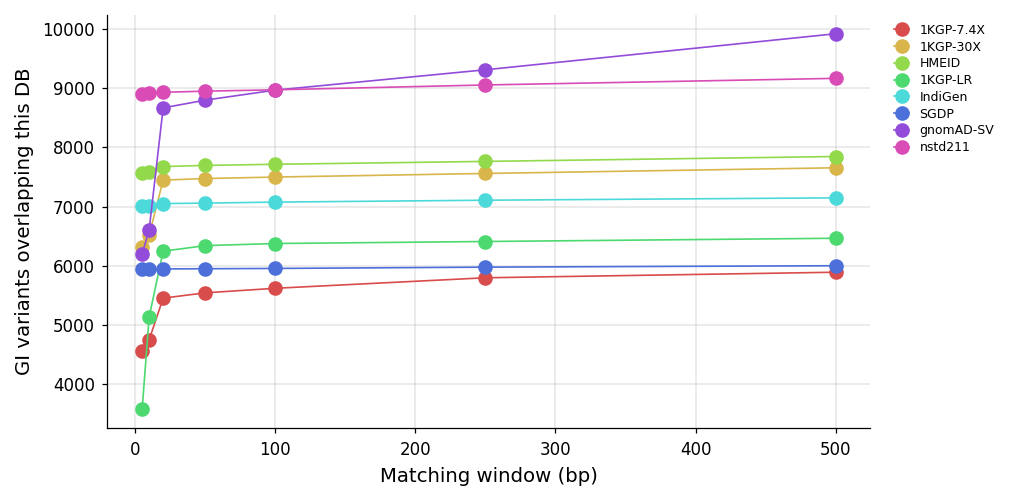

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import fig_style as S

S.set_style()

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/"
os.makedirs(OUTDIR, exist_ok=True)
TMPDIR = "/tmp/alu_window_vjgS"

novel = pd.read_csv(f"{TMPDIR}/novel_by_window.tsv", sep="\t")
perdb = pd.read_csv(f"{TMPDIR}/overlap_by_window_and_db.tsv", sep="\t")

print("Novel ALU variants (not in ANY db) by window size:")
display(novel)

pivot = perdb.pivot(index="window_bp", columns="source_vcf", values="gi_variants_overlapping")
print("\nOverlapping variant counts by window size and source DB:")
display(pivot.rename(columns=get_db_short_label))

print("\nDB code key:")
display(db_key_table())

fig2, ax2 = plt.subplots(figsize=(S.COL2, S.COL2 * 0.5), facecolor="white")
for col in pivot.columns:
    ax2.plot(pivot.index, pivot[col], marker="o", label=get_db_short_label(col), color=get_db_color(col))
ax2.set_xlabel("Matching window (bp)")
ax2.set_ylabel("GI variants overlapping this DB")
ax2.legend(
    loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.3,
    fontsize=6, handlelength=1.2, labelspacing=0.3, frameon=False,
)
ax2.grid(alpha=0.3)
plt.tight_layout()
S.save(fig2, os.path.join(OUTDIR, "per_db_ALU_overlap_by_window"))
plt.show()

In [8]:
%%bash
module load bcftools-1.21
module load bedtools-2.30


GI_VCF="/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz"

LR_SR_VCFS=(
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_ALU.vcf.gz" #1KGP MELT 7.4X VCF
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_ALU.vcf.gz" #1KGP 3202 30X VCF
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/hg38_longreads_SVAN/INS.ALU.solo.hg38.vcf.gz" #1KGP LR VCF
    "/gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_ALU.vcf.gz" #gnomad SV VCF
    "/gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_ALU.vcf.gz" #SGDP VCF
     "/gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.ALU.dedup.vcf.gz" #nstd211 VCF
    "/gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.ALU.vcf.gz" #HMEID VCF
    "/gpfs/data/user/ruchitha/MELT/Analysis/NoveltyCheck/databases/IndiGen/Indigen_Alu_final_geno10_all_22K.vcf.gz" #Indigen VCF
)

OUTFILE=~/af_all_ALU_not_in_ANY_SR.txt
OVERLAP_SUMMARY=~/af_all_ALU_overlap_by_source.txt
TMPDIR=$(mktemp -d)
WINDOW=20

AF_THRESHOLD=0 #if changing to common varinats change this

bcftools view -H "${GI_VCF}" \
| awk -F'\t' -v AFTHRESH="${AF_THRESHOLD}" '{
    split($8, info, ";");
    for (i in info) {
        if (info[i] ~ /^AF=/) {
            split(info[i], af, "=");
            if (af[2]+0 >= AFTHRESH)
                print $1"\t"$2"\t"$2
        }
    }
}' \
| sort -k1,1 -k2,2n \
> "${TMPDIR}/gi_coords.txt"

N_GI=$(wc -l < "${TMPDIR}/gi_coords.txt")
echo "GI variants (AF>0.2): ${N_GI}"

# extracting coordinates for each vcf

> "${TMPDIR}/lr_union.txt"   
> "${OVERLAP_SUMMARY}"      

echo -e "source_vcf\tgi_variants_overlapping\tpct_of_gi_variants" > "${OVERLAP_SUMMARY}"

for VCF in "${LR_SR_VCFS[@]}"; do
    if [[ ! -f "$VCF" ]]; then
        echo "WARNING: skipping missing file: $VCF"
        continue
    fi

    echo "Processing: $VCF"
    BASENAME=$(basename "$VCF")
    PERVCF_COORDS="${TMPDIR}/$(basename "$VCF" .vcf.gz).coords.txt"

    bcftools query -f '%CHROM\t%POS\t%POS\n' "${VCF}" \
    | awk 'BEGIN{OFS="\t"}{
        chrom = $1
        if (chrom !~ /^chr/) chrom = "chr"chrom
        print chrom, $2, $3
    }' \
    | sort -k1,1 -k2,2n \
    > "${PERVCF_COORDS}"

    cat "${PERVCF_COORDS}" >> "${TMPDIR}/lr_union.txt"

    N_VCF=$(wc -l < "${PERVCF_COORDS}")

    #how many GI variants fall within +/-WINDOW bp of ANY variant in this specific source VCF.
    bedtools window \
        -a "${TMPDIR}/gi_coords.txt" \
        -b "${PERVCF_COORDS}" \
        -w "${WINDOW}" \
    | cut -f1-3 \
    | sort -u \
    > "${TMPDIR}/gi_matched_thisvcf.txt"

    N_MATCHED=$(wc -l < "${TMPDIR}/gi_matched_thisvcf.txt")
    PCT=$(awk -v m="${N_MATCHED}" -v t="${N_GI}" 'BEGIN{ if (t==0) print "NA"; else printf "%.2f", (m/t)*100 }')

    echo "  ${BASENAME}: ${N_VCF} variants in source, ${N_MATCHED} GI variants overlap (${PCT}%)"
    echo -e "${BASENAME}\t${N_MATCHED}\t${PCT}" >> "${OVERLAP_SUMMARY}"
done

echo ""
echo "Per-source overlap summary:"
column -t "${OVERLAP_SUMMARY}"
echo ""
echo "Per-source overlap summary saved to: ${OVERLAP_SUMMARY}"

# union to find total number of unreported variants

sort -k1,1 -k2,2n "${TMPDIR}/lr_union.txt" \
| uniq \
> "${TMPDIR}/lr_union_sorted.txt"

echo ""
echo "Total LR/SR coords (union, deduplicated): $(wc -l < ${TMPDIR}/lr_union_sorted.txt)"

bedtools window \
    -a "${TMPDIR}/gi_coords.txt" \
    -b "${TMPDIR}/lr_union_sorted.txt" \
    -w "${WINDOW}" \
| cut -f1-3 \
| sort -u \
> "${TMPDIR}/gi_matched.txt"

echo "GI variants found in at least one LR/SR VCF: $(wc -l < ${TMPDIR}/gi_matched.txt)"

bedtools intersect \
    -a "${TMPDIR}/gi_coords.txt" \
    -b "${TMPDIR}/gi_matched.txt" \
    -v \
> "${OUTFILE}"

echo "GI variants NOT in any LR/SR VCF: $(wc -l < ${OUTFILE})"
echo "Saved to ${OUTFILE}"

NOVEL_VCF=~/TE_work/filtered_vcfs/novel_ALU.vcf.gz

# Convert the not-in-any coords to a regions file bcftools can use
awk 'BEGIN{OFS="\t"}{print $1, $2, $2}' "${OUTFILE}" > "${TMPDIR}/novel_regions.txt"

bcftools view \
    -R "${TMPDIR}/novel_regions.txt" \
    "${GI_VCF}" \
    -O z -o "${NOVEL_VCF}"

bcftools index -t "${NOVEL_VCF}"

echo "Novel ALU VCF: $(bcftools view -H ${NOVEL_VCF} | wc -l) variants"
echo "Saved to ${NOVEL_VCF}"

rm -r "${TMPDIR}"

[W::bcf_hdr_check_sanity] GL should be declared as Number=G


GI variants (AF>0.2): 26977
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_ALU.vcf.gz
  1kgp_INS_ALU.vcf.gz: 12743 variants in source, 5449 GI variants overlap (20.20%)
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_ALU.vcf.gz
  3202_30X_1KGP_INS_ALU.vcf.gz: 29036 variants in source, 7447 GI variants overlap (27.60%)
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/hg38_longreads_SVAN/INS.ALU.solo.hg38.vcf.gz


[W::bcf_hrec_check] Invalid tag name: "5PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_SEQ"


  INS.ALU.solo.hg38.vcf.gz: 23084 variants in source, 6244 GI variants overlap (23.15%)
Processing: /gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_ALU.vcf.gz
  gnomad_INS_ALU.vcf.gz: 173374 variants in source, 8670 GI variants overlap (32.14%)
Processing: /gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_ALU.vcf.gz
  SGDP_INS_ALU.vcf.gz: 11661 variants in source, 5944 GI variants overlap (22.03%)
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.ALU.dedup.vcf.gz
  nstd211.ALU.dedup.vcf.gz: 41254 variants in source, 8934 GI variants overlap (33.12%)
Processing: /gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.ALU.vcf.gz
  HMEID.ALU.vcf.gz: 26553 variants in source, 7677 GI variants overlap (28.46%)
Processing: /gpfs/data/user/ruchitha/MELT/Analysis/NoveltyCheck/databases/IndiGen/Indigen_Alu_final_geno10_all_22K.vcf.gz
  Indigen_Alu_final_geno10_all_22K.vcf.gz: 21981 variants in source, 7050 GI variants overlap (26.13%)

Per-source overlap summary:
source_vcf 

[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G


Novel ALU VCF: 14224 variants
Saved to /gpfs/data/user/shreyags/TE_work/filtered_vcfs/novel_ALU.vcf.gz


In [13]:
import gzip
import numpy as np

ALU_INS_VCFS = [
    "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/annotated_genotyped/INS.ALU.solo.mapped.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_ALU.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_ALU.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.ALU.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.ALU.dedup.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kGP2504.high_coverage.ALU.accessioned.fixed.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kGP698.high_coverage.ALU.accessioned.fixed.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_ALU.vcf.gz",
    "/gpfs/data/user/ruchitha/MELT/Analysis/NoveltyCheck/databases/IndiGen/Indigen_Alu_final_geno10_all_22K.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_ALU.vcf.gz",
]

MISSING_GTS = {"./.", ".|."}

def count_per_sample(vcf_path):
    counts = None
    with gzip.open(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                samples = line.strip().split("\t")[9:]
                counts = np.zeros(len(samples), dtype=int)
                continue
            if line.startswith("#"):
                continue
            if counts is None:
                continue
            genotypes = line.strip().split("\t")[9:]
            for i, gtfield in enumerate(genotypes):
                gt = gtfield.split(":")[0]
                if gt in MISSING_GTS:
                    continue
                if "1" in gt:
                    counts[i] += 1
    return counts

print("ALU insertions")
print(f"{'VCF':50s} {'n_samples':>10s} {'mean':>10s} {'sd':>10s} {'min':>6s} {'max':>6s}")
print("-" * 95)

alu_rows = []
for vcf_path in ALU_INS_VCFS:
    basename = vcf_path.split("/")[-1]
    try:
        counts = count_per_sample(vcf_path)
    except FileNotFoundError:
        print(f"{basename:50s}  WARNING: file not found, skipping")
        continue
    except OSError as e:
        print(f"{basename:50s}  WARNING: could not read ({e}), skipping")
        continue

    if counts is None or len(counts) == 0:
        print(f"{basename:50s}  WARNING: no samples found in header, skipping")
        continue

    mean = np.mean(counts)
    sd = np.std(counts, ddof=1) if len(counts) > 1 else 0.0
    n = len(counts)

    print(f"{basename:50s} {n:10d} {mean:10.2f} {sd:10.2f} {counts.min():6d} {counts.max():6d}")

    alu_rows.append({
        "vcf": basename, "path": vcf_path, "n_samples": n,
        "mean": mean, "sd": sd, "min": int(counts.min()), "max": int(counts.max()),
    })

ALU_OUTFILE = "ALU_INS_per_individual_mean_sd_by_source.txt"
with open(ALU_OUTFILE, "w") as out:
    out.write("source_vcf\tn_samples\tmean\tsd\tmin\tmax\n")
    for r in alu_rows:
        out.write(f"{r['vcf']}\t{r['n_samples']}\t{r['mean']:.4f}\t{r['sd']:.4f}\t{r['min']}\t{r['max']}\n")

print(f"\nSaved -> {ALU_OUTFILE}")

ALU insertions
VCF                                                 n_samples       mean         sd    min    max
-----------------------------------------------------------------------------------------------
ALU.filtered.final.tagged.vcf.gz                         7478     943.72      24.98    479   1153
INS.ALU.solo.mapped.vcf.gz                                967    1334.92     209.39    762   1758
3202_30X_1KGP_INS_ALU.vcf.gz                             3202     902.71     102.12    750   1169
1kgp_INS_ALU.vcf.gz                                      2504     896.55     181.95    378   1389
HMEID.ALU.vcf.gz                                    WARNING: no samples found in header, skipping
nstd211.ALU.dedup.vcf.gz                            WARNING: no samples found in header, skipping
1kGP2504.high_coverage.ALU.accessioned.fixed.vcf.gz       2504    1685.28     156.42   1457   2081
1kGP698.high_coverage.ALU.accessioned.fixed.vcf.gz        698    1531.03     161.81   1321   1853
SGDP_I

In [9]:
%%bash
module load bcftools-1.21
module load bedtools-2.30

GI_VCF="/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz"

LR_SR_VCFS=(
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/hg38_longreads_SVAN/INS.LINE1.solo.hg38.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_LINE1.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_LINE1.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.LINE1.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.LINE1.dedup.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_LINE1.vcf.gz"
    "/gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_LINE1.vcf.gz"
)

WINDOWS=(5 10 20 50 100 250 500)
AF_THRESHOLD=0

TMPDIR=$(mktemp -d /tmp/line1_window_XXXX)
echo "TMPDIR=${TMPDIR}"   

NOVEL_TSV="${TMPDIR}/novel_by_window.tsv"
PERDB_TSV="${TMPDIR}/overlap_by_window_and_db.tsv"

echo -e "window_bp\tnovel_count\tpct_of_gi_variants" > "${NOVEL_TSV}"
echo -e "window_bp\tsource_vcf\tgi_variants_overlapping\tpct_of_gi_variants" > "${PERDB_TSV}"

bcftools view -H "${GI_VCF}" \
| awk -F'\t' -v AFTHRESH="${AF_THRESHOLD}" '{
    split($8, info, ";");
    for (i in info) {
        if (info[i] ~ /^AF=/) {
            split(info[i], af, "=");
            if (af[2]+0 >= AFTHRESH)
                print $1"\t"$2"\t"$2
        }
    }
}' \
| sort -k1,1 -k2,2n \
> "${TMPDIR}/gi_coords.txt"

N_GI=$(wc -l < "${TMPDIR}/gi_coords.txt")
echo "GI variants (AF>=${AF_THRESHOLD}): ${N_GI}"

declare -A PERVCF_COORD_FILES

for VCF in "${LR_SR_VCFS[@]}"; do
    if [[ ! -f "$VCF" ]]; then
        echo "WARNING: skipping missing file: $VCF"
        continue
    fi
    BASENAME=$(basename "$VCF")
    PERVCF_COORDS="${TMPDIR}/$(basename "$VCF" .vcf.gz).coords.txt"

    bcftools query -f '%CHROM\t%POS\t%POS\n' "${VCF}" \
    | awk 'BEGIN{OFS="\t"}{
        chrom = $1
        if (chrom !~ /^chr/) chrom = "chr"chrom
        print chrom, $2, $3
    }' \
    | sort -k1,1 -k2,2n \
    > "${PERVCF_COORDS}"

    PERVCF_COORD_FILES["${BASENAME}"]="${PERVCF_COORDS}"
done

> "${TMPDIR}/lr_union.txt"
for BASENAME in "${!PERVCF_COORD_FILES[@]}"; do
    cat "${PERVCF_COORD_FILES[$BASENAME]}" >> "${TMPDIR}/lr_union.txt"
done
sort -k1,1 -k2,2n "${TMPDIR}/lr_union.txt" | uniq > "${TMPDIR}/lr_union_sorted.txt"
echo "Total LR/SR coords (union, deduplicated): $(wc -l < ${TMPDIR}/lr_union_sorted.txt)"
echo ""

#loop over window sizes 
for WINDOW in "${WINDOWS[@]}"; do
    echo "WINDOW = ${WINDOW} bp"

    for BASENAME in "${!PERVCF_COORD_FILES[@]}"; do
        PERVCF_COORDS="${PERVCF_COORD_FILES[$BASENAME]}"

        bedtools window -a "${TMPDIR}/gi_coords.txt" -b "${PERVCF_COORDS}" -w "${WINDOW}" \
        | cut -f1-3 | sort -u > "${TMPDIR}/gi_matched_thisvcf.txt"

        N_MATCHED=$(wc -l < "${TMPDIR}/gi_matched_thisvcf.txt")
        PCT=$(awk -v m="${N_MATCHED}" -v t="${N_GI}" 'BEGIN{ if (t==0) print "NA"; else printf "%.2f", (m/t)*100 }')

        echo "  ${BASENAME}: ${N_MATCHED} GI variants overlap (${PCT}%)"
        echo -e "${WINDOW}\t${BASENAME}\t${N_MATCHED}\t${PCT}" >> "${PERDB_TSV}"
    done

    bedtools window -a "${TMPDIR}/gi_coords.txt" -b "${TMPDIR}/lr_union_sorted.txt" -w "${WINDOW}" \
    | cut -f1-3 | sort -u > "${TMPDIR}/gi_matched.txt"

    bedtools intersect -a "${TMPDIR}/gi_coords.txt" -b "${TMPDIR}/gi_matched.txt" -v \
    > "${TMPDIR}/gi_novel_thiswindow.txt"

    N_NOVEL=$(wc -l < "${TMPDIR}/gi_novel_thiswindow.txt")
    PCT_NOVEL=$(awk -v m="${N_NOVEL}" -v t="${N_GI}" 'BEGIN{ if (t==0) print "NA"; else printf "%.2f", (m/t)*100 }')

    echo "NOVEL (not in any LR/SR VCF): ${N_NOVEL} (${PCT_NOVEL}%)"
    echo -e "${WINDOW}\t${N_NOVEL}\t${PCT_NOVEL}" >> "${NOVEL_TSV}"
    echo ""
done

echo "# Novel variant counts by window size"
column -t "${NOVEL_TSV}"

echo "# Per-DB overlap counts by window size"
column -t "${PERDB_TSV}"

TMPDIR=/tmp/line1_window_Dk9U


[W::bcf_hdr_check_sanity] GL should be declared as Number=G


GI variants (AF>=0): 7075


[W::bcf_hrec_check] Invalid tag name: "5PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_SEQ"


Total LR/SR coords (union, deduplicated): 47332

WINDOW = 5 bp
  gnomad_INS_LINE1.vcf.gz: 1327 GI variants overlap (18.76%)
  3202_30X_1KGP_INS_LINE1.vcf.gz: 782 GI variants overlap (11.05%)
  HMEID.LINE1.vcf.gz: 1259 GI variants overlap (17.80%)
  SGDP_INS_LINE1.vcf.gz: 879 GI variants overlap (12.42%)
  nstd211.LINE1.dedup.vcf.gz: 1720 GI variants overlap (24.31%)
  INS.LINE1.solo.hg38.vcf.gz: 679 GI variants overlap (9.60%)
  1kgp_INS_LINE1.vcf.gz: 730 GI variants overlap (10.32%)
NOVEL (not in any LR/SR VCF): 4773 (67.46%)

WINDOW = 10 bp
  gnomad_INS_LINE1.vcf.gz: 1370 GI variants overlap (19.36%)
  3202_30X_1KGP_INS_LINE1.vcf.gz: 783 GI variants overlap (11.07%)
  HMEID.LINE1.vcf.gz: 1265 GI variants overlap (17.88%)
  SGDP_INS_LINE1.vcf.gz: 880 GI variants overlap (12.44%)
  nstd211.LINE1.dedup.vcf.gz: 1723 GI variants overlap (24.35%)
  INS.LINE1.solo.hg38.vcf.gz: 868 GI variants overlap (12.27%)
  1kgp_INS_LINE1.vcf.gz: 767 GI variants overlap (10.84%)
NOVEL (not in any LR/SR 

Novel LINE1 variants (not in ANY db) by window size:


,window_bp,novel_count,pct_of_gi_variants
0,5,4773,67.46
1,10,4769,67.41
2,20,4758,67.25
3,50,4742,67.02
4,100,4726,66.80
5,250,4687,66.25
6,500,4650,65.72



Overlapping variant counts by window size and source DB:


source_vcf,1KGP-7.4X,1KGP-30X,HMEID,1KGP-LR,SGDP,gnomAD-SV,nstd211
window_bp,,,,,,,
5,730,782,1259,679,879,1327,1720
10,767,783,1265,868,880,1370,1723
20,917,797,1300,1001,880,1553,1728
50,945,804,1304,1006,882,1597,1733
100,959,808,1307,1008,882,1633,1737
250,990,812,1319,1011,887,1663,1751
500,1007,815,1330,1020,888,1699,1771



DB code key:


,label,source_db
0,1KGP-30X,3202_30X_1KGP_INS
1,1KGP-7.4X,1kgp_INS
2,1KGP-LR,INS_solo_hg38
3,HMEID,HMEID
4,IndiGen,Indigen_final_geno10_all_22K
5,SGDP,SGDP_INS
6,gnomAD-SV,gnomad_INS
7,nstd211,nstd211_dedup


  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/per_db_LINE1_overlap_by_window.pdf / .png


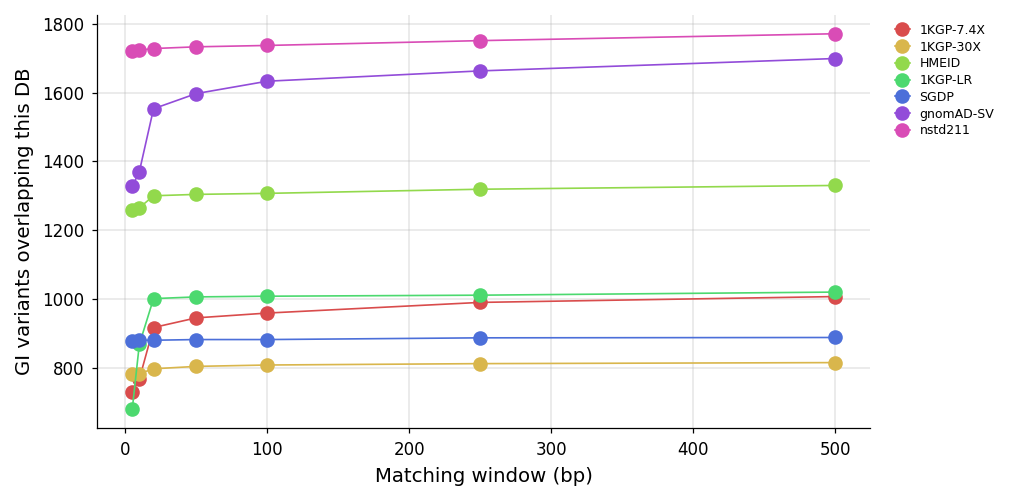

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import fig_style as S

S.set_style()

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/"
os.makedirs(OUTDIR, exist_ok=True)
TMPDIR = "/tmp/line1_window_Dk9U"

novel = pd.read_csv(f"{TMPDIR}/novel_by_window.tsv", sep="\t")
perdb = pd.read_csv(f"{TMPDIR}/overlap_by_window_and_db.tsv", sep="\t")

print("Novel LINE1 variants (not in ANY db) by window size:")
display(novel)

pivot = perdb.pivot(index="window_bp", columns="source_vcf", values="gi_variants_overlapping")
print("\nOverlapping variant counts by window size and source DB:")
display(pivot.rename(columns=get_db_short_label))

print("\nDB code key:")
display(db_key_table())

fig2, ax2 = plt.subplots(figsize=(S.COL2, S.COL2 * 0.5), facecolor="white")
for col in pivot.columns:
    ax2.plot(pivot.index, pivot[col], marker="o", label=get_db_short_label(col), color=get_db_color(col))
ax2.set_xlabel("Matching window (bp)")
ax2.set_ylabel("GI variants overlapping this DB")
ax2.legend(
    loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.3,
    fontsize=6, handlelength=1.2, labelspacing=0.3, frameon=False,
)
ax2.grid(alpha=0.3)
plt.tight_layout()
S.save(fig2, os.path.join(OUTDIR, "per_db_LINE1_overlap_by_window"))
plt.show()

In [11]:
%%bash
module load bcftools-1.21
module load bedtools-2.30

GI_VCF="/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz"

LR_SR_VCFS=(
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_LINE1.vcf.gz" #1KGP MELT 7.4X VCF
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_LINE1.vcf.gz" #1KGP 3202 30X VCF
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/hg38_longreads_SVAN/INS.LINE1.solo.hg38.vcf.gz" #1KGP LR VCF
    "/gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_LINE1.vcf.gz" #gnomad SV VCF
    "/gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_LINE1.vcf.gz" #SGDP VCF
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.LINE1.dedup.vcf.gz" #nstd211 VCF
    "/gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.LINE1.vcf.gz" #HMEID VCF
)

OUTFILE=~/af_all_LINE1_not_in_ANY_SR.txt
OVERLAP_SUMMARY=~/af_all_LINE1_overlap_by_source.txt
TMPDIR=$(mktemp -d)
WINDOW=20

AF_THRESHOLD=0 #if changing to common varinats change this

bcftools view -H "${GI_VCF}" \
| awk -F'\t' -v AFTHRESH="${AF_THRESHOLD}" '{
    split($8, info, ";");
    for (i in info) {
        if (info[i] ~ /^AF=/) {
            split(info[i], af, "=");
            if (af[2]+0 >= AFTHRESH)
                print $1"\t"$2"\t"$2
        }
    }
}' \
| sort -k1,1 -k2,2n \
> "${TMPDIR}/gi_coords.txt"

N_GI=$(wc -l < "${TMPDIR}/gi_coords.txt")
echo "GI variants (AF>0.2): ${N_GI}"

# extracting coordinates for each vcf

> "${TMPDIR}/lr_union.txt" 
> "${OVERLAP_SUMMARY}"       

echo -e "source_vcf\tgi_variants_overlapping\tpct_of_gi_variants" > "${OVERLAP_SUMMARY}"

for VCF in "${LR_SR_VCFS[@]}"; do
    if [[ ! -f "$VCF" ]]; then
        echo "WARNING: skipping missing file: $VCF"
        continue
    fi

    echo "Processing: $VCF"
    BASENAME=$(basename "$VCF")
    PERVCF_COORDS="${TMPDIR}/$(basename "$VCF" .vcf.gz).coords.txt"

    bcftools query -f '%CHROM\t%POS\t%POS\n' "${VCF}" \
    | awk 'BEGIN{OFS="\t"}{
        chrom = $1
        if (chrom !~ /^chr/) chrom = "chr"chrom
        print chrom, $2, $3
    }' \
    | sort -k1,1 -k2,2n \
    > "${PERVCF_COORDS}"

    cat "${PERVCF_COORDS}" >> "${TMPDIR}/lr_union.txt"

    N_VCF=$(wc -l < "${PERVCF_COORDS}")

    #how many GI variants fall within +/-WINDOW bp of ANY variant in this specific source VCF.
    bedtools window \
        -a "${TMPDIR}/gi_coords.txt" \
        -b "${PERVCF_COORDS}" \
        -w "${WINDOW}" \
    | cut -f1-3 \
    | sort -u \
    > "${TMPDIR}/gi_matched_thisvcf.txt"

    N_MATCHED=$(wc -l < "${TMPDIR}/gi_matched_thisvcf.txt")
    PCT=$(awk -v m="${N_MATCHED}" -v t="${N_GI}" 'BEGIN{ if (t==0) print "NA"; else printf "%.2f", (m/t)*100 }')

    echo "  ${BASENAME}: ${N_VCF} variants in source, ${N_MATCHED} GI variants overlap (${PCT}%)"
    echo -e "${BASENAME}\t${N_MATCHED}\t${PCT}" >> "${OVERLAP_SUMMARY}"
done

echo ""
echo "Per-source overlap summary:"
column -t "${OVERLAP_SUMMARY}"
echo ""
echo "Per-source overlap summary saved to: ${OVERLAP_SUMMARY}"


sort -k1,1 -k2,2n "${TMPDIR}/lr_union.txt" \
| uniq \
> "${TMPDIR}/lr_union_sorted.txt"

echo ""
echo "Total LR/SR coords (union, deduplicated): $(wc -l < ${TMPDIR}/lr_union_sorted.txt)"

bedtools window \
    -a "${TMPDIR}/gi_coords.txt" \
    -b "${TMPDIR}/lr_union_sorted.txt" \
    -w "${WINDOW}" \
| cut -f1-3 \
| sort -u \
> "${TMPDIR}/gi_matched.txt"

echo "GI variants found in at least one LR/SR VCF: $(wc -l < ${TMPDIR}/gi_matched.txt)"

bedtools intersect \
    -a "${TMPDIR}/gi_coords.txt" \
    -b "${TMPDIR}/gi_matched.txt" \
    -v \
> "${OUTFILE}"

echo "GI variants NOT in any LR/SR VCF: $(wc -l < ${OUTFILE})"
echo "Saved to ${OUTFILE}"

NOVEL_VCF=~/TE_work/filtered_vcfs/novel_LINE1.vcf.gz

# Convert the not-in-any coords to a regions file bcftools can use
awk 'BEGIN{OFS="\t"}{print $1, $2, $2}' "${OUTFILE}" > "${TMPDIR}/novel_regions.txt"

bcftools view \
    -R "${TMPDIR}/novel_regions.txt" \
    "${GI_VCF}" \
    -O z -o "${NOVEL_VCF}"

bcftools index -t "${NOVEL_VCF}"

echo "Novel LINE1 VCF: $(bcftools view -H ${NOVEL_VCF} | wc -l) variants"
echo "Saved to ${NOVEL_VCF}"

rm -r "${TMPDIR}"

[W::bcf_hdr_check_sanity] GL should be declared as Number=G


GI variants (AF>0.2): 7075
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_LINE1.vcf.gz
  1kgp_INS_LINE1.vcf.gz: 3047 variants in source, 917 GI variants overlap (12.96%)
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_LINE1.vcf.gz
  3202_30X_1KGP_INS_LINE1.vcf.gz: 2967 variants in source, 797 GI variants overlap (11.27%)
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/hg38_longreads_SVAN/INS.LINE1.solo.hg38.vcf.gz


[W::bcf_hrec_check] Invalid tag name: "5PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_NB_TD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_MAPQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TD_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_MOB_GENE"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "5PRIME_TEMP_SEQ"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_LEN"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_COORD"
[W::bcf_hrec_check] Invalid tag name: "3PRIME_TEMP_SEQ"


  INS.LINE1.solo.hg38.vcf.gz: 4446 variants in source, 1001 GI variants overlap (14.15%)
Processing: /gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_LINE1.vcf.gz
  gnomad_INS_LINE1.vcf.gz: 30223 variants in source, 1553 GI variants overlap (21.95%)
Processing: /gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_LINE1.vcf.gz
  SGDP_INS_LINE1.vcf.gz: 1886 variants in source, 880 GI variants overlap (12.44%)
Processing: /gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.LINE1.dedup.vcf.gz
  nstd211.LINE1.dedup.vcf.gz: 10956 variants in source, 1728 GI variants overlap (24.42%)
Processing: /gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.LINE1.vcf.gz
  HMEID.LINE1.vcf.gz: 7353 variants in source, 1300 GI variants overlap (18.37%)

Per-source overlap summary:
source_vcf                      gi_variants_overlapping  pct_of_gi_variants
1kgp_INS_LINE1.vcf.gz           917                      12.96
3202_30X_1KGP_INS_LINE1.vcf.gz  797                      11.27
INS.LINE1.solo.hg38.v

[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G


Novel LINE1 VCF: 4758 variants
Saved to /gpfs/data/user/shreyags/TE_work/filtered_vcfs/novel_LINE1.vcf.gz


In [12]:
import gzip
import numpy as np

LINE1_INS_VCFS = [
    "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/annotated_genotyped/INS.LINE1.solo.mapped.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/3202_30X_1KGP_INS_LINE1.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kgp_INS_LINE1.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/HMEID/HMEID.LINE1.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/nstd211.LINE1.dedup.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kGP2504.high_coverage.LINE1.accessioned.fixed.vcf.gz", #nstd211 2504 samples
    "/gpfs/data/user/shreyags/TE_work/data/1kgp/1kGP698.high_coverage.LINE1.accessioned.fixed.vcf.gz", #nstd211 698 samples
    "/gpfs/data/user/shreyags/TE_work/data/SGDP/SGDP_INS_LINE1.vcf.gz",
    "/gpfs/data/user/shreyags/TE_work/data/gnomad_sv/gnomad_INS_LINE1.vcf.gz",
]


MISSING_GTS = {"./.", ".|."}

def count_per_sample(vcf_path):
    counts = None
    with gzip.open(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                samples = line.strip().split("\t")[9:]
                counts = np.zeros(len(samples), dtype=int)
                continue
            if line.startswith("#"):
                continue
            if counts is None:
                continue
            genotypes = line.strip().split("\t")[9:]
            for i, gtfield in enumerate(genotypes):
                gt = gtfield.split(":")[0]
                if gt in MISSING_GTS:
                    continue
                if "1" in gt:
                    counts[i] += 1
    return counts

print("LINE1 insertions")
print(f"{'VCF':50s} {'n_samples':>10s} {'mean':>10s} {'sd':>10s} {'min':>6s} {'max':>6s}")
print("-" * 95)

line1_rows = []
for vcf_path in LINE1_INS_VCFS:
    basename = vcf_path.split("/")[-1]
    try:
        counts = count_per_sample(vcf_path)
    except FileNotFoundError:
        print(f"{basename:50s}  WARNING: file not found, skipping")
        continue
    except OSError as e:
        print(f"{basename:50s}  WARNING: could not read ({e}), skipping")
        continue

    if counts is None or len(counts) == 0:
        print(f"{basename:50s}  WARNING: no samples found in header, skipping")
        continue

    mean = np.mean(counts)
    sd = np.std(counts, ddof=1) if len(counts) > 1 else 0.0
    n = len(counts)

    print(f"{basename:50s} {n:10d} {mean:10.2f} {sd:10.2f} {counts.min():6d} {counts.max():6d}")

    line1_rows.append({
        "vcf": basename, "path": vcf_path, "n_samples": n,
        "mean": mean, "sd": sd, "min": int(counts.min()), "max": int(counts.max()),
    })

LINE1_OUTFILE = "LINE1_INS_per_individual_mean_sd_by_source.txt"
with open(LINE1_OUTFILE, "w") as out:
    out.write("source_vcf\tn_samples\tmean\tsd\tmin\tmax\n")
    for r in line1_rows:
        out.write(f"{r['vcf']}\t{r['n_samples']}\t{r['mean']:.4f}\t{r['sd']:.4f}\t{r['min']}\t{r['max']}\n")

print(f"\nSaved -> {LINE1_OUTFILE}")

LINE1 insertions
VCF                                                 n_samples       mean         sd    min    max
-----------------------------------------------------------------------------------------------
LINE1.filtered.final.tagged.vcf.gz                       7478     107.51       7.43     56    135
INS.LINE1.solo.mapped.vcf.gz                              967     187.16      26.75     90    255
3202_30X_1KGP_INS_LINE1.vcf.gz                           3202      78.62       9.00     50    122
1kgp_INS_LINE1.vcf.gz                                    2504     128.27      21.99     52    188
HMEID.LINE1.vcf.gz                                  WARNING: no samples found in header, skipping
nstd211.LINE1.dedup.vcf.gz                          WARNING: no samples found in header, skipping
1kGP2504.high_coverage.LINE1.accessioned.fixed.vcf.gz       2504     296.88      18.54    250    368
1kGP698.high_coverage.LINE1.accessioned.fixed.vcf.gz        698     193.21      18.55    152    246


  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/combined_per_db_ALU_LINE1_overlap_by_window.pdf / .png


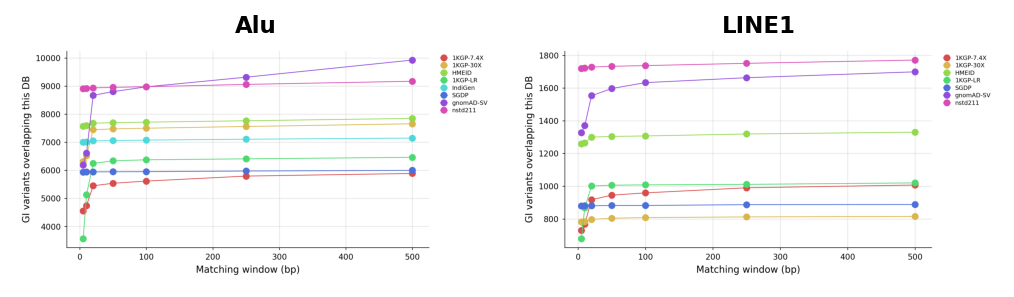

In [2]:
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import fig_style as S

S.set_style()

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/"


def combine_side_by_side(path_left, path_right, out_path_noext, label_left="Alu", label_right="LINE1"):
    img_left = mpimg.imread(path_left)
    img_right = mpimg.imread(path_right)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(S.COL2, S.COL2 * 0.43), facecolor="white")

    axL.set_facecolor("white")
    axL.imshow(img_left)
    axL.axis("off")
    axL.set_title(label_left, fontweight="bold")

    axR.set_facecolor("white")
    axR.imshow(img_right)
    axR.axis("off")
    axR.set_title(label_right, fontweight="bold")

    plt.tight_layout()
    S.save(fig, out_path_noext)
    plt.show()

combine_side_by_side(
    os.path.join(OUTDIR, "per_db_ALU_overlap_by_window.png"),
    os.path.join(OUTDIR, "per_db_LINE1_overlap_by_window.png"),
    os.path.join(OUTDIR, "combined_per_db_ALU_LINE1_overlap_by_window"),
)